# Regresión logística para predicciones bancarias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("../datasets/bank/bank.csv", sep =";")

In [4]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [5]:
data.shape

(4119, 21)

In [6]:
data.columns.values

array(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'], dtype=object)

In [7]:
data["y"] = (data["y"]=="yes").astype(int)

In [8]:
data.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
4114,30,admin.,married,basic.6y,no,yes,yes,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,0
4115,39,admin.,married,high.school,no,yes,no,telephone,jul,fri,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0
4116,27,student,single,high.school,no,no,no,cellular,may,mon,...,2,999,1,failure,-1.8,92.893,-46.2,1.354,5099.1,0
4117,58,admin.,married,high.school,no,no,no,cellular,aug,fri,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,0
4118,34,management,single,high.school,no,yes,no,cellular,nov,wed,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,0


In [9]:
data["education"].unique()

array(['basic.9y', 'high.school', 'university.degree',
       'professional.course', 'basic.6y', 'basic.4y', 'unknown',
       'illiterate'], dtype=object)

In [10]:
data["education"] = np.where(data["education"]=="basic.4y", "Basic", data["education"])
data["education"] = np.where(data["education"]=="basic.6y", "Basic", data["education"])
data["education"] = np.where(data["education"]=="basic.9y", "Basic", data["education"])

data["education"] = np.where(data["education"]=="high.school", "High School", data["education"])
data["education"] = np.where(data["education"]=="professional.course", "Professional Course", data["education"])
data["education"] = np.where(data["education"]=="university.degree", "University Degree", data["education"])

data["education"] = np.where(data["education"]=="illiterate", "Illiterate", data["education"])
data["education"] = np.where(data["education"]=="unknown", "Unknown", data["education"])

In [11]:
data["education"].unique()

array(['Basic', 'High School', 'University Degree', 'Professional Course',
       'Unknown', 'Illiterate'], dtype=object)

In [12]:
data["y"].value_counts()

0    3668
1     451
Name: y, dtype: int64

In [13]:
data.groupby("y").mean()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
y,,,,,,,,,,
0,39.895311,219.40976,2.605780,982.763086,0.141767,0.240185,93.599677,-40.586723,3.802826,5175.502072
1,41.889135,560.78714,1.980044,778.722838,0.585366,-1.177384,93.417268,-39.786475,2.145448,5093.118625


In [14]:
data.groupby("education").mean()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
education,,,,,,,,,,,
Basic,42.337124,253.898457,2.429732,978.815597,0.149472,0.237368,93.658600,-41.120552,3.775701,5174.133144,0.079610
High School,38.097720,258.534202,2.630836,958.022801,0.206298,-0.002497,93.564314,-40.995765,3.511732,5163.212595,0.105320
Illiterate,42.000000,146.000000,4.000000,999.000000,0.000000,-2.900000,92.201000,-31.400000,0.834000,5076.200000,0.000000
Professional Course,40.207477,278.816822,2.512150,958.211215,0.194393,0.163925,93.599630,-40.127664,3.701426,5167.595140,0.121495
University Degree,39.017405,247.707278,2.583070,947.900316,0.207278,-0.009731,93.499109,-39.830063,3.547132,5163.023180,0.130538
Unknown,42.826347,267.281437,2.538922,939.700599,0.263473,-0.074251,93.637455,-39.487425,3.410174,5151.260479,0.155689


Text(0, 0.5, 'Frecuencia de compras del producto')

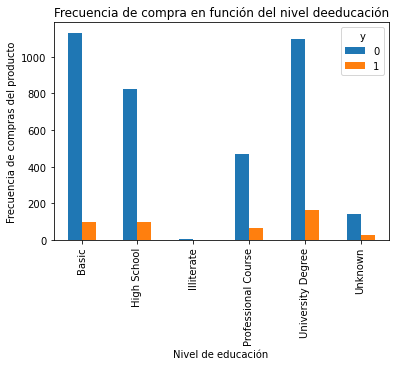

In [15]:
%matplotlib inline
pd.crosstab(data.education, data.y).plot(kind="bar")
plt.title("Frecuencia de compra en función del nivel deeducación")
plt.xlabel("Nivel de educación")
plt.ylabel("Frecuencia de compras del producto")

Text(0, 0.5, 'Proporción de clientes')

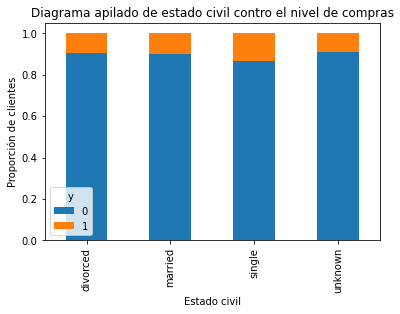

In [16]:
table = pd.crosstab(data.marital, data.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)
plt.title("Diagrama apilado de estado civil contro el nivel de compras")
plt.xlabel("Estado civil")
plt.ylabel("Proporción de clientes")

Text(0, 0.5, 'Frecuencia de compras del producto')

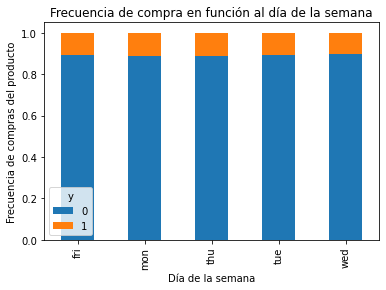

In [17]:
%matplotlib inline
# pd.crosstab(data.day_of_week, data.y).plot(kind="bar")
table = pd.crosstab(data.day_of_week, data.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)
plt.title("Frecuencia de compra en función al día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Frecuencia de compras del producto")

Text(0, 0.5, 'Frecuencia de compras del producto')

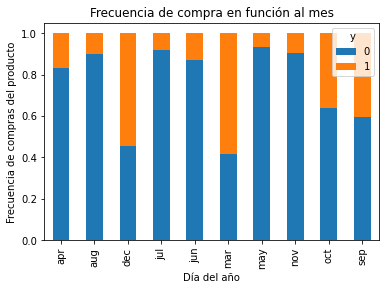

In [18]:
%matplotlib inline
table = pd.crosstab(data.month, data.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)
plt.title("Frecuencia de compra en función al mes")
plt.xlabel("Día del año")
plt.ylabel("Frecuencia de compras del producto")

Text(0, 0.5, 'Frecuencia de compras del producto')

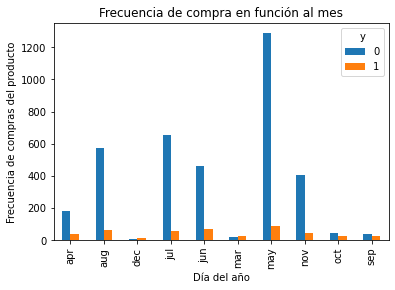

In [19]:
%matplotlib inline
pd.crosstab(data.month, data.y).plot(kind="bar")
plt.title("Frecuencia de compra en función al mes")
plt.xlabel("Día del año")
plt.ylabel("Frecuencia de compras del producto")

Text(0, 0.5, 'Cleinte')

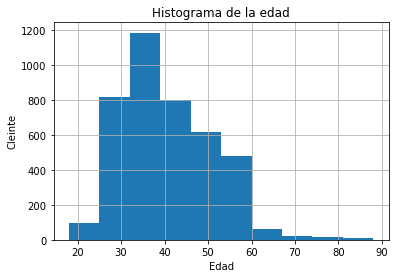

In [20]:
%matplotlib inline
data.age.hist()
plt.title("Histograma de la edad")
plt.xlabel("Edad")
plt.ylabel("Cleinte")

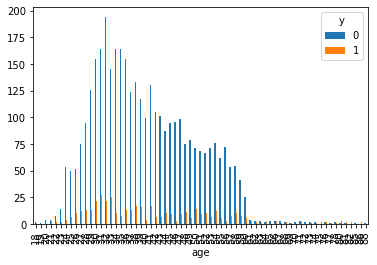

In [21]:
pd.crosstab(data.age, data.y).plot(kind="bar")

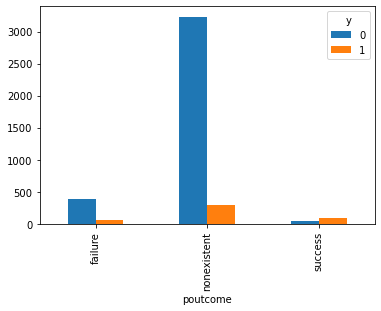

In [22]:
pd.crosstab(data.poutcome, data.y).plot(kind="bar")

### Conversión de las variables categóricas a dummys

In [23]:
categories = ["job", "marital", "education", "housing", "loan", "contact", "month", "day_of_week", "poutcome"]
for caregory in categories:
    cat_list = "cat"+"_"+caregory
    cat_dummies = pd.get_dummies(data[caregory], prefix=cat_list)
    data_new = data.join(cat_dummies)
    data = data_new

In [24]:
data_vars = data.columns.values.tolist()

In [25]:
to_keep = [v for v in data_vars if v not in categories]
to_keep = [v for v in to_keep if v not in ["default"]]

In [26]:
bank_data = data[to_keep]

In [27]:
bank_data.columns.values

array(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
       'cat_job_admin.', 'cat_job_blue-collar', 'cat_job_entrepreneur',
       'cat_job_housemaid', 'cat_job_management', 'cat_job_retired',
       'cat_job_self-employed', 'cat_job_services', 'cat_job_student',
       'cat_job_technician', 'cat_job_unemployed', 'cat_job_unknown',
       'cat_marital_divorced', 'cat_marital_married',
       'cat_marital_single', 'cat_marital_unknown', 'cat_education_Basic',
       'cat_education_High School', 'cat_education_Illiterate',
       'cat_education_Professional Course',
       'cat_education_University Degree', 'cat_education_Unknown',
       'cat_housing_no', 'cat_housing_unknown', 'cat_housing_yes',
       'cat_loan_no', 'cat_loan_unknown', 'cat_loan_yes',
       'cat_contact_cellular', 'cat_contact_telephone', 'cat_month_apr',
       'cat_month_aug', 'cat_month_dec', 'cat_month_jul', 'cat_mon

In [28]:
bank_data_vars = bank_data.columns.values.tolist()
Y = ['y']
X = [v for v in bank_data_vars if v not in Y]

### Selección de rasgos para el modelo

In [29]:
n = 12

In [30]:
from sklearn import datasets
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

ImportError: DLL load failed: No se encontró el proceso especificado.

In [ ]:
lr = LogisticRegression()

In [ ]:
rfe = RFE(lr, n)

In [ ]:
rfe = rfe.fit(bank_data[X], bank_data[Y].values.ravel())

In [33]:
bank_data.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,cat_month_oct,cat_month_sep,cat_day_of_week_fri,cat_day_of_week_mon,cat_day_of_week_thu,cat_day_of_week_tue,cat_day_of_week_wed,cat_poutcome_failure,cat_poutcome_nonexistent,cat_poutcome_success
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,0,0,1,0,0,0,0,0,1,0
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,0,0,1,0,0,0,0,0,1,0
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,0,0,0,0,0,0,1,0,1,0
3,38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1,...,0,0,1,0,0,0,0,0,1,0
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,0,0,0,1,0,0,0,0,1,0


In [34]:
print(rfe.support_)

[False False False False  True False False False  True False False False
 False False False  True False False False  True  True False False False
 False False False False False False False False False False False False
 False False False False False False  True  True  True  True  True False
 False False False False False False False  True False  True]


In [35]:
print(rfe.ranking_)

[40 39 18 45  1 17 26 22  1 35  2  8  5 38  7  1  6 24 42  1  1 41 15 28
 27 47 31 12 46 19 30  4  9 14 43 13 20 32 11  3 37 21  1  1  1  1  1 23
 33 44 34 25 29 36 10  1 16  1]


In [36]:
z = zip(bank_data_vars, rfe.support_, rfe.ranking_)

In [37]:
list(z)

[('age', False, 40),
 ('duration', False, 39),
 ('campaign', False, 18),
 ('pdays', False, 45),
 ('previous', True, 1),
 ('emp.var.rate', False, 17),
 ('cons.price.idx', False, 26),
 ('cons.conf.idx', False, 22),
 ('euribor3m', True, 1),
 ('nr.employed', False, 35),
 ('y', False, 2),
 ('cat_job_admin.', False, 8),
 ('cat_job_blue-collar', False, 5),
 ('cat_job_entrepreneur', False, 38),
 ('cat_job_housemaid', False, 7),
 ('cat_job_management', True, 1),
 ('cat_job_retired', False, 6),
 ('cat_job_self-employed', False, 24),
 ('cat_job_services', False, 42),
 ('cat_job_student', True, 1),
 ('cat_job_technician', True, 1),
 ('cat_job_unemployed', False, 41),
 ('cat_job_unknown', False, 15),
 ('cat_marital_divorced', False, 28),
 ('cat_marital_married', False, 27),
 ('cat_marital_single', False, 47),
 ('cat_marital_unknown', False, 31),
 ('cat_education_Basic', False, 12),
 ('cat_education_High School', False, 46),
 ('cat_education_Illiterate', False, 19),
 ('cat_education_Professional Cou

In [38]:
cols = ["previous", "euribor3m", "cat_job_blue-collar", "cat_job_retired", "cat_month_aug", "cat_month_dec", 
        "cat_month_jul", "cat_month_jun", "cat_month_mar", "cat_month_nov", "cat_day_of_week_wed", "cat_poutcome_nonexistent"]

In [39]:
X = bank_data[cols]
Y = bank_data['y']

### Implementación del modelo en Python con statsmodel.api

In [40]:
import statsmodels.api as sm

In [41]:
logit_model = sm.Logit(Y, X)

In [42]:
result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.291770
         Iterations 7


In [43]:
result.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                             Results: Logit
=========================================================================
Model:                  Logit              Pseudo R-squared:   0.155     
Dependent Variable:     y                  AIC:                2427.6025 
Date:                   2020-05-11 02:30   BIC:                2503.4828 
No. Observations:       4119               Log-Likelihood:     -1201.8   
Df Model:               11                 LL-Null:            -1422.9   
Df Residuals:           4107               LLR p-value:        6.4492e-88
Converged:              1.0000             Scale:              1.0000    
No. Iterations:         7.0000                                           
-------------------------------------------------------------------------
                          Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------------
previous                 -0.1229   0.0700  -1.7545 0.0793 -0.2601  0.0144
euribor3m                -0.6049   0.0383 -15.7882 0.0000 -0.6800 -0.5298
cat_job_blue-collar      -0.5032   0.1519  -3.3136 0.0009 -0.8009 -0.2056
cat_job_retired           0.2235   0.2191   1.0205 0.3075 -0.2058  0.6529
cat_month_aug             0.6048   0.1759   3.4374 0.0006  0.2600  0.9497
cat_month_dec             1.1358   0.4493   2.5281 0.0115  0.2552  2.0163
cat_month_jul             1.0327   0.1910   5.4071 0.0000  0.6584  1.4070
cat_month_jun             1.0775   0.1752   6.1493 0.0000  0.7341  1.4210
cat_month_mar             1.6448   0.3139   5.2407 0.0000  1.0297  2.2600
cat_month_nov             0.3828   0.1950   1.9634 0.0496  0.0007  0.7649
cat_day_of_week_wed      -0.0649   0.1391  -0.4665 0.6409 -0.3375  0.2077
cat_poutcome_nonexistent -0.7753   0.1221  -6.3492 0.0000 -1.0147 -0.5360
=========================================================================

"""

### implementación del modelo en Python con scikit-learn

In [44]:
from sklearn import linear_model

In [45]:
logit_model = linear_model.LogisticRegression()
logit_model.fit(X,Y)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [46]:
logit_model.score(X,Y) # mientras másalto mejor

0.8958485069191552

In [47]:
Y.mean()

0.10949259529011895

In [48]:
pd.DataFrame(list(zip(X.columns, np.transpose(logit_model.coef_))))

,0,1
0,previous,[0.5362541179381511]
1,euribor3m,[-0.5443670397995588]
2,cat_job_blue-collar,[-0.3533138743513581]
3,cat_job_retired,[0.36165159081175685]
4,cat_month_aug,[0.629258889506849]
5,cat_month_dec,[1.1943974572118183]
6,cat_month_jul,[0.963055414066067]
7,cat_month_jun,[1.0566897056469142]
8,cat_month_mar,[1.6386680234584563]
9,cat_month_nov,[0.45770841910588395]


### Validación del modelo logístico

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state=0)

In [51]:
lm = linear_model.LogisticRegression()
lm.fit(X_train, Y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [52]:
from IPython.display import display, Math, Latex

In [53]:
display(Math(r'Y_p\begin{cases}0& si\ p\leq0.5\\1&si\ p >0.5\end{cases}'))

<IPython.core.display.Math object>

In [54]:
probs = lm.predict_proba(X_test)

In [55]:
probs

array([[0.95409621, 0.04590379],
       [0.83896646, 0.16103354],
       [0.93216535, 0.06783465],
       ...,
       [0.65098445, 0.34901555],
       [0.97381005, 0.02618995],
       [0.57635748, 0.42364252]])

In [56]:
prediction = lm.predict(X_test)

In [57]:
prediction

array([0, 0, 0, ..., 0, 0, 0])

In [58]:
display(Math(r'\varepsilon\in (0,1), Y_p\begin{cases}0& si\ p\leq\varepsilon\\1&si\ p >\varepsilon\end{cases}'))

<IPython.core.display.Math object>

In [59]:
prob = probs[:, 1]
probs_df = pd.DataFrame(prob)
threshold = 0.1
probs_df["prediction"] = np.where(probs_df[0]>threshold, 1, 0)
probs_df.head()

,0,prediction
0,0.045904,0
1,0.161034,1
2,0.067835,0
3,0.062222,0
4,0.042308,0


In [60]:
pd.crosstab(probs_df.prediction, columns="count")

col_0,count
prediction,
0,846
1,390


In [61]:
390/len(probs_df)*100

31.55339805825243

In [62]:
threshold = 0.15
probs_df["prediction"] = np.where(probs_df[0]>threshold, 1, 0)
pd.crosstab(probs_df.prediction, columns="count")

col_0,count
prediction,
0,915
1,321


In [63]:
331/len(probs_df)*100

26.779935275080906

In [64]:
threshold = 0.05
probs_df["prediction"] = np.where(probs_df[0]>threshold, 1, 0)
pd.crosstab(probs_df.prediction, columns="count")

col_0,count
prediction,
0,504
1,732


In [65]:
732/len(probs_df)*100

59.22330097087378

In [66]:
from sklearn import metrics

In [67]:
metrics.accuracy_score(Y_test, prediction)

0.901294498381877

## Validación cruzada

In [68]:
from sklearn.model_selection import cross_val_score

In [69]:
scores = cross_val_score(linear_model.LogisticRegression(), X, Y, scoring="accuracy", cv=10)

In [70]:
scores

array([0.90533981, 0.88834951, 0.90533981, 0.89563107, 0.90048544,
       0.8907767 , 0.88349515, 0.89320388, 0.89320388, 0.88807786])

In [71]:
scores.mean()

0.8943903101599225

## Matrices de Confusión y curvas ROC

In [72]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.3, random_state=0)

In [73]:
lm = linear_model.LogisticRegression()
lm.fit(X_train, Y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [74]:
probs = lm.predict_proba(X_test)

In [75]:
prob = probs[:,1]
probs_df = pd.DataFrame(prob)
threshold = 0.1
probs_df["prediction"] = np.where(probs_df[0]>=threshold,1,0)
probs_df["actual"]     = list(Y_test)
probs_df.head()

,0,prediction,actual
0,0.045904,0,0
1,0.161034,1,0
2,0.067835,0,0
3,0.062222,0,0
4,0.042308,0,0


In [76]:
confusion_matrix = pd.crosstab(probs_df.prediction, probs_df.actual)

In [77]:
TN = confusion_matrix[0][0]
TP = confusion_matrix[1][1]
FP = confusion_matrix[0][1]
FN = confusion_matrix[1][0]

In [78]:
sens = TP/(TP+FN)
sens

0.6721311475409836

In [79]:
expc_1 = 1-TN/(TN+FP)
expc_1

0.2764811490125674

In [80]:
thresholds = [0.04, 0.05, 0.07, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.3, 0.4, 0.5]
sensitivities = [1]
especifities_1 = [1]

for t in thresholds:    
    probs_df["prediction"] = np.where(probs_df[0]>=t, 1, 0)
    probs_df["actual"]     = list(Y_test)
    probs_df.head()

    confusion_matrix = pd.crosstab(probs_df.prediction, probs_df.actual)
    TN = confusion_matrix[0][0]
    TP = confusion_matrix[1][1]
    FP = confusion_matrix[0][1]
    FN = confusion_matrix[1][0]

    sens = TP/(TP+FN)
    sensitivities.append(sens)
    expc_1 = 1-TN/(TN+FP)
    especifities_1.append(expc_1)
    
sensitivities.append(0)
especifities_1.append(0)

In [82]:
sensitivities

[1,
 0.9344262295081968,
 0.8442622950819673,
 0.680327868852459,
 0.6721311475409836,
 0.6639344262295082,
 0.6229508196721312,
 0.5163934426229508,
 0.45081967213114754,
 0.4016393442622951,
 0.36065573770491804,
 0.1721311475409836,
 0.12295081967213115,
 0]

In [83]:
especifities_1

[1,
 0.7800718132854578,
 0.5646319569120287,
 0.2989228007181328,
 0.2764811490125674,
 0.24596050269299818,
 0.21992818671454217,
 0.12387791741472176,
 0.08617594254937166,
 0.07181328545780974,
 0.06463195691202872,
 0.022441651705565557,
 0.013464991023339312,
 0]

In [84]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Curva ROC')

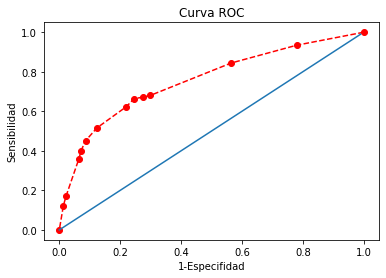

In [85]:
%matplotlib inline
plt.plot(especifities_1, sensitivities, marker="o", linestyle="--", color="r")
x=[i*0.01 for i in range(100)]
y=[i*0.01 for i in range(100)]
plt.plot(x,y)
plt.xlabel("1-Especifidad")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC")

In [87]:
from sklearn import metrics
from ggplot import *

ModuleNotFoundError: No module named 'ggplot'